In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!ls '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/AMELOBLASTOMA/40X'

imagen_100.png	imagen_159.png	imagen_216.png	imagen_274.png	imagen_45.png
imagen_101.png	imagen_15.png	imagen_217.png	imagen_275.png	imagen_46.png
imagen_102.png	imagen_160.png	imagen_218.png	imagen_276.png	imagen_47.png
imagen_103.png	imagen_161.png	imagen_219.png	imagen_277.png	imagen_48.png
imagen_104.png	imagen_162.png	imagen_21.png	imagen_278.png	imagen_49.png
imagen_105.png	imagen_163.png	imagen_220.png	imagen_279.png	imagen_4.png
imagen_106.png	imagen_164.png	imagen_221.png	imagen_27.png	imagen_50.png
imagen_107.png	imagen_165.png	imagen_222.png	imagen_280.png	imagen_51.png
imagen_108.png	imagen_166.png	imagen_223.png	imagen_281.png	imagen_52.png
imagen_109.png	imagen_167.png	imagen_224.png	imagen_282.png	imagen_53.png
imagen_10.png	imagen_168.png	imagen_225.png	imagen_283.png	imagen_54.png
imagen_110.png	imagen_169.png	imagen_226.png	imagen_284.png	imagen_55.png
imagen_111.png	imagen_16.png	imagen_227.png	imagen_285.png	imagen_56.png
imagen_112.png	imagen_170.png	imagen_228.png

In [22]:

# Importar librerías necesarias
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [23]:
# Definir las rutas específicas de cada clase
class_1_dir = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/AMELOBLASTOMA/40X'
class_2_dir = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/DENTIGEROUS/40X'
class_3_dir = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/KERATOCYST/40X'
class_4_dir = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/DENTAL/40X'
class_5_dir = '/content/drive/MyDrive/GorlinIA/A_D_K_CROPPED/ORTHOKERATINIZED/40X'



In [24]:
# Parámetros de las imágenes
img_size = (128, 128)

# Función para cargar imágenes desde una carpeta y realizar aumentación
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def load_and_augment_images(folder, label, img_size, augment=True):
    images = []
    labels = []
    datagen = ImageDataGenerator(
        rotation_range=20,  # Rotación aleatoria
        horizontal_flip=True,  # Espejo horizontal
        fill_mode='nearest'
    )

    for filename in os.listdir(folder):
        if filename.endswith(('png', 'jpg', 'jpeg')):  # Filtrar solo imágenes
            img_path = os.path.join(folder, filename)
            img = load_img(img_path, target_size=img_size)
            img_array = img_to_array(img) / 255.0  # Normalizar entre 0 y 1
            images.append(img_array)
            labels.append(label)

            # Aumentación de datos
            if augment:
                img_array = np.expand_dims(img_array, axis=0)  # Expandir dimensiones
                for _ in range(2):  # Generar 2 imágenes augmentadas por cada imagen original
                    aug_img = datagen.flow(img_array, batch_size=1)[0]
                    images.append(aug_img[0])
                    labels.append(label)

    return images, labels


In [25]:
# Cargar imágenes y etiquetas desde cada carpeta
class_1_images, class_1_labels = load_and_augment_images(class_1_dir, 0, img_size)
class_2_images, class_2_labels = load_and_augment_images(class_2_dir, 1, img_size)
class_3_images, class_3_labels = load_and_augment_images(class_3_dir, 2, img_size)
class_4_images, class_4_labels = load_and_augment_images(class_4_dir, 3, img_size)
class_5_images, class_5_labels = load_and_augment_images(class_5_dir, 4, img_size)

# Combinar todas las imágenes y etiquetas
all_images = np.array(class_1_images + class_2_images + class_3_images + class_4_images + class_5_images)
all_labels = np.array(class_1_labels + class_2_labels + class_3_labels + class_4_labels + class_5_labels)


In [28]:
import numpy as np

def sample_per_class(images, labels, n_samples=705, seed=42):
    images = np.array(images)
    labels = np.array(labels)

    np.random.seed(seed)
    idx = np.random.choice(len(images), size=n_samples, replace=False)

    return images[idx], labels[idx]


In [29]:
class_1_images, class_1_labels = sample_per_class(
    class_1_images, class_1_labels, n_samples=705
)

class_2_images, class_2_labels = sample_per_class(
    class_2_images, class_2_labels, n_samples=705
)

class_3_images, class_3_labels = sample_per_class(
    class_3_images, class_3_labels, n_samples=705
)

class_4_images, class_4_labels = sample_per_class(
    class_4_images, class_4_labels, n_samples=705
)

class_5_images, class_5_labels = sample_per_class(
    class_5_images, class_5_labels, n_samples=705
)


In [30]:
all_images = np.concatenate([
    class_1_images,
    class_2_images,
    class_3_images,
    class_4_images,
    class_5_images
], axis=0)

all_labels = np.concatenate([
    class_1_labels,
    class_2_labels,
    class_3_labels,
    class_4_labels,
    class_5_labels
], axis=0)


In [32]:
len(class_3_images)

705

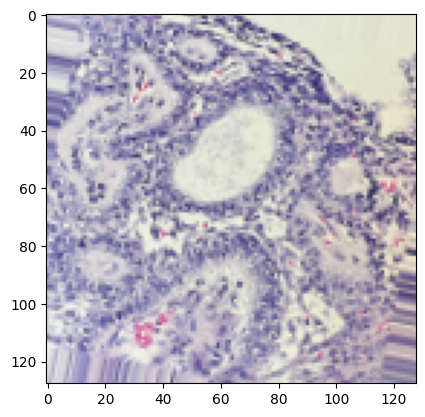

In [33]:
import matplotlib.pyplot as plt

# Índice de la imagen a visualizar
idx = 0  # Cambia este número para ver diferentes imágenes

# Mostrar la imagen
plt.imshow(all_images[idx])  # Asegúrate de que X_val está normalizado correctamente (0-1 o 0-255)


In [34]:
# Barajar los datos
all_images, all_labels = shuffle(all_images, all_labels, random_state=42)


In [35]:
all_labels

array([0, 3, 4, ..., 1, 4, 4])

In [36]:
# Dividir en conjunto de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(all_images, all_labels, test_size=0.2, random_state=42)

# Convertir las etiquetas a formato one-hot
y_train = tf.keras.utils.to_categorical(y_train, num_classes=5)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=5)


In [37]:
# Crear el modelo con DenseNet
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(5, activation='softmax')  # 4 clases
])

# Compilar el modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [48]:
# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=13,
    batch_size=32
)


Epoch 1/13
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9418 - val_loss: 0.1978
Epoch 2/13
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9461 - val_loss: 0.2006
Epoch 3/13
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9418 - val_loss: 0.2015
Epoch 4/13
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9418 - val_loss: 0.2012
Epoch 5/13
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9418 - val_loss: 0.2062
Epoch 6/13
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9447 - val_loss: 0.2029
Epoch 7/13
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9418 - val_loss: 0.2062
Epoch 8/13
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9461 - v

In [49]:
X_val.shape

(705, 128, 128, 3)

In [50]:
# Guardar el modelo
model.save('/content/drive/MyDrive/densenet_4_classes_model.h5')


In [51]:
# Evaluar el modelo
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Loss en validación: {val_loss:.4f}")
print(f"Precisión en validación: {val_accuracy:.4f}")


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9519 - loss: 0.1836
Loss en validación: 0.2058
Precisión en validación: 0.9461


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


<Figure size 1000x1000 with 0 Axes>

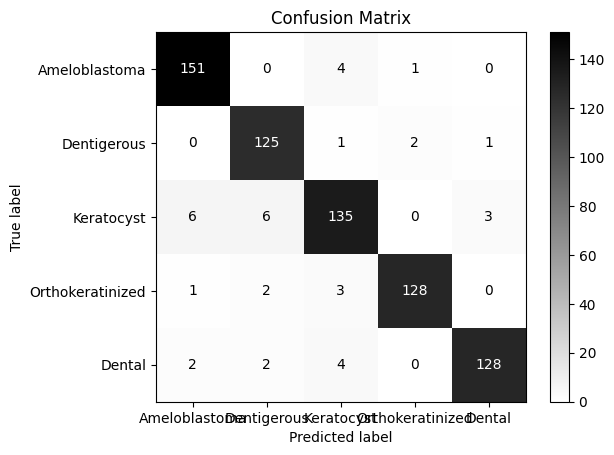

In [53]:
# Predicciones y matriz de confusión
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ameloblastoma', 'Dentigerous', 'Keratocyst', 'Orthokeratinized', 'Dental'])

# Graficar la matriz de confusión
plt.figure(figsize=(10, 10))
disp.plot(cmap=plt.cm.gist_grey_r, values_format='.0f')
plt.title("Confusion Matrix")
plt.show()

In [18]:
# Encontrar los índices donde la predicción no coincide con la etiqueta real
errores_idx = np.where(y_pred_classes != y_true)[0]

# Mostrar los primeros 10 errores con su etiqueta real y predicha
for idx in errores_idx[:]:  # Cambia 10 por el número que quieras visualizar
    print(f"Índice: {idx} | Real: {y_true[idx]} | Predicho: {y_pred_classes[idx]}")


Índice: 6 | Real: 0 | Predicho: 2
Índice: 20 | Real: 1 | Predicho: 2
Índice: 25 | Real: 4 | Predicho: 2
Índice: 36 | Real: 0 | Predicho: 4
Índice: 37 | Real: 3 | Predicho: 1
Índice: 43 | Real: 4 | Predicho: 2
Índice: 61 | Real: 0 | Predicho: 4
Índice: 73 | Real: 1 | Predicho: 3
Índice: 81 | Real: 2 | Predicho: 4
Índice: 98 | Real: 0 | Predicho: 4
Índice: 191 | Real: 2 | Predicho: 0
Índice: 200 | Real: 2 | Predicho: 1
Índice: 205 | Real: 1 | Predicho: 4
Índice: 215 | Real: 2 | Predicho: 0
Índice: 247 | Real: 2 | Predicho: 4
Índice: 248 | Real: 3 | Predicho: 0
Índice: 292 | Real: 2 | Predicho: 4
Índice: 312 | Real: 2 | Predicho: 4
Índice: 322 | Real: 3 | Predicho: 2
Índice: 333 | Real: 0 | Predicho: 2
Índice: 335 | Real: 2 | Predicho: 4
Índice: 395 | Real: 1 | Predicho: 2
Índice: 421 | Real: 2 | Predicho: 0
Índice: 447 | Real: 0 | Predicho: 1
Índice: 465 | Real: 2 | Predicho: 0
Índice: 466 | Real: 3 | Predicho: 0
Índice: 481 | Real: 2 | Predicho: 0
Índice: 492 | Real: 4 | Predicho: 2
Índ

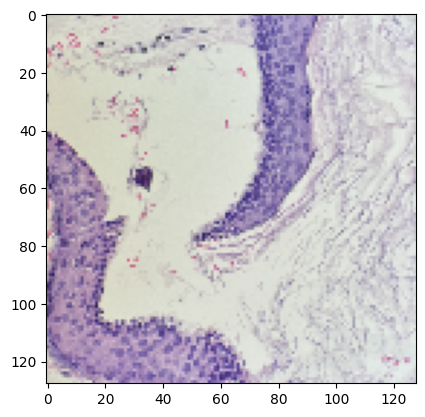

In [19]:
import matplotlib.pyplot as plt

# Índice de la imagen a visualizar
idx = 487  # Cambia este número para ver diferentes imágenes

# Mostrar la imagen
plt.imshow(X_val[idx])  # Asegúrate de que X_val está normalizado correctamente (0-1 o 0-255)
